<a href="https://colab.research.google.com/github/codyzhou64-art/nba-diagrams/blob/main/DAML_HW01_Signal_Rescue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DAML Homework 1 — Signal Rescue
## From vectors and probability to gradient descent

**Mandatory core: 30–45 minutes · Optional deep dive: 45–90+ minutes · 100 points + 10 bonus**

Two inexpensive sensors are observing the same changing environment. Neither sensor is perfect. Your job is to learn a linear calibration model that combines their readings into a reliable estimate.

The complete pipeline is the compact machine-learning story from Lecture 2:

$$
x \xrightarrow{f_\theta} \hat y, \qquad
\theta^* = \arg\min_\theta L(\theta).
$$

You will implement the forward model, describe its errors statistically, connect squared error to a Gaussian likelihood, derive a gradient, and optimize the parameters from scratch.

<div style="border-left: 5px solid #2f855a; padding: 0.8em 1em; background: #f0fff4;">
<b>Learning objectives</b><br>
By the end, you should be able to:
<ol>
  <li>reason about vector and matrix shapes;</li>
  <li>translate a mathematical loss into vectorized NumPy;</li>
  <li>use the chain rule to obtain a parameter gradient;</li>
  <li>implement and diagnose batch gradient descent;</li>
  <li>distinguish a useful fitted model from literal “truth.”</li>
</ol>
</div>

## Working policy: make a real attempt first

AI tools may be used **as a tutor when you are stuck**, after you have made a fair initial attempt. Good uses include asking for a hint, requesting an explanation of an error, or checking your reasoning. You remain responsible for understanding every submitted line and for being able to reproduce the ideas independently on the cumulative end-of-semester assessment.

Conceptual discussion with classmates is encouraged. Do not exchange completed code or submit work you cannot explain.

At the end of the notebook, briefly disclose any substantial assistance you used.

## Submission contract

- Complete only cells marked **YOUR CODE** or **YOUR RESPONSE**.
- Keep every required function name and signature unchanged.
- Use only NumPy and Matplotlib in the mandatory section.
- Do **not** use automatic differentiation, `np.linalg.lstsq`, `np.linalg.solve`, `np.linalg.pinv`, scikit-learn, or an optimizer library for the required gradient-descent implementation.
- Before submitting: **Restart kernel/runtime → Run all**.

Public checks are intentionally small. Hidden tests use different shapes and values, so hard-coded answers will not survive contact with reality.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## Mission setup

Each row of `X` is one observation. The columns are:

1. a constant `1` for the intercept;
2. Sensor A's reading;
3. Sensor B's reading.

The target `y` is a reference temperature. The random seed is fixed so everyone receives the same data.

In [2]:
# Deterministic synthetic calibration data. No downloads are required.
rng = np.random.default_rng(7)
n_examples = 96

# A hidden environmental signal influences both sensors.
latent_signal = rng.normal(loc=0.0, scale=1.0, size=n_examples)
sensor_a = latent_signal + rng.normal(loc=0.0, scale=0.22, size=n_examples)
sensor_b = 0.65 * latent_signal + rng.normal(loc=0.0, scale=0.55, size=n_examples)

# The first column of ones lets the model learn an intercept.
X_all = np.column_stack([np.ones(n_examples), sensor_a, sensor_b])
theta_data_generating = np.array([22.0, 2.2, 1.4])
y_all = X_all @ theta_data_generating + rng.normal(loc=0.0, scale=0.55, size=n_examples)

# Keep a small test set that gradient descent never sees.
permutation = rng.permutation(n_examples)
train_idx, test_idx = permutation[:72], permutation[72:]
X_train, y_train = X_all[train_idx], y_all[train_idx]
X_test, y_test = X_all[test_idx], y_all[test_idx]

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print("First three rows of X_train:\n", X_train[:3])
print("First three targets:", y_train[:3])

X_train shape: (72, 3)
y_train shape: (72,)
First three rows of X_train:
 [[ 1.     -1.5215 -0.3763]
 [ 1.      0.7895  1.0497]
 [ 1.      0.8749  0.1455]]
First three targets: [18.1629 25.2371 24.9669]


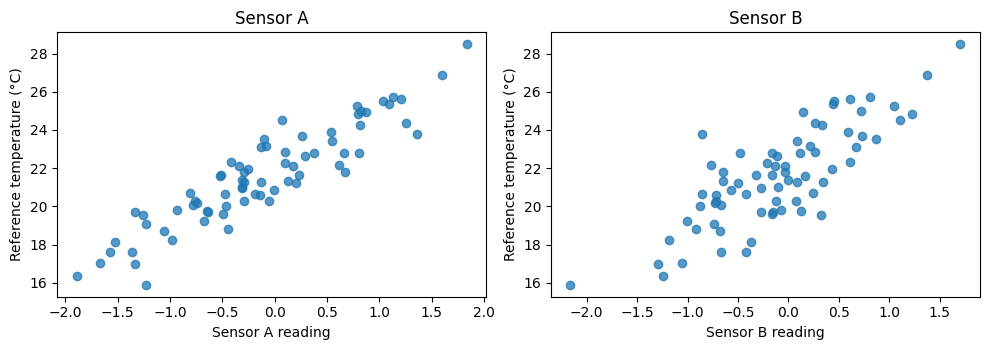

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].scatter(X_train[:, 1], y_train, alpha=0.75)
axes[0].set(xlabel="Sensor A reading", ylabel="Reference temperature (°C)", title="Sensor A")
axes[1].scatter(X_train[:, 2], y_train, alpha=0.75)
axes[1].set(xlabel="Sensor B reading", ylabel="Reference temperature (°C)", title="Sensor B")
plt.tight_layout()
plt.show()

### Shape checkpoint — ungraded

Without running extra code, predict the shapes of:

- `X_train[0]`
- `X_train[:, 1]`
- `X_train @ np.zeros(3)`

Then verify your prediction below.

In [4]:
print("X_train[0].shape:", X_train[0].shape)
print("X_train[:, 1].shape:", X_train[:, 1].shape)
print("(X_train @ np.zeros(3)).shape:", (X_train @ np.zeros(3)).shape)

X_train[0].shape: (3,)
X_train[:, 1].shape: (72,)
(X_train @ np.zeros(3)).shape: (72,)


## Part 1 — The forward model `X @ θ` (12 points, ~5 minutes)

For a linear model,

$$
\hat y = X\theta.
$$

Implement `predict`. It must work for any compatible `(n, d)` matrix and `(d,)` parameter vector.

> **YOUR CODE:** one vectorized expression is enough.

In [5]:
def predict(X, theta):
    """Return one prediction per row of X as a one-dimensional NumPy array."""
    # TODO: replace the next line with your implementation.
    return np.dot(X,theta)

In [6]:
X_tiny = np.array([[1.0, 2.0], [1.0, -1.0]])
theta_tiny = np.array([3.0, 4.0])
expected = np.array([11.0, -1.0])

assert np.allclose(predict(X_tiny, theta_tiny), expected)
assert predict(X_tiny, theta_tiny).shape == (2,)
print("✓ Public check passed")

✓ Public check passed


## Part 2 — Error as a distribution (14 points, ~5 minutes)

Define the residual for each example as

$$
r_i = y_i - \hat y_i.
$$

Implement `residual_statistics` and return three Python floats:

1. mean residual;
2. **population** variance, using denominator `n` (`ddof=0`);
3. standard deviation.

A mean near zero says errors are balanced on average. Variance and standard deviation describe their spread.

> **YOUR CODE:** use vectorized NumPy. No loop is needed.

In [7]:
def residual_statistics(y, y_hat):
    """Return (mean_residual, population_variance, standard_deviation) as floats."""
    # TODO: replace the next line with your implementation.
    r = np.asarray(y)-np.asarray(y_hat)
    return float(np.mean(r)),float(np.var(r)), float(np.std(r))

In [8]:
y_tiny = np.array([1.0, 2.0, 5.0])
y_hat_tiny = np.array([0.0, 2.0, 3.0])
mean_r, var_r, std_r = residual_statistics(y_tiny, y_hat_tiny)

assert np.isclose(mean_r, 1.0)
assert np.isclose(var_r, 2.0 / 3.0)
assert np.isclose(std_r, np.sqrt(2.0 / 3.0))
print("✓ Public check passed")

✓ Public check passed


In [9]:
# A deliberately rough baseline model.
theta_baseline = np.array([20.0, 1.0, 1.0])
y_hat_baseline = predict(X_train, theta_baseline)

baseline_stats = residual_statistics(y_train, y_hat_baseline)
print("Baseline residual mean, variance, std:", baseline_stats)

Baseline residual mean, variance, std: (1.8264827877976808, 1.5783565306722545, 1.2563266019121997)


## Part 3 — From squared error to Gaussian negative log-likelihood (19 points, ~7 minutes)

Assume each target is distributed around the prediction with Gaussian noise:

$$
y_i \mid x_i,\theta \sim \mathcal N(\hat y_i, \sigma^2).
$$

The **mean negative log-likelihood** is

$$
\operatorname{NLL}
= \frac{1}{n}\sum_{i=1}^{n}
\left[
\frac{1}{2}\log(2\pi\sigma^2)
+ \frac{(y_i-\hat y_i)^2}{2\sigma^2}
\right].
$$

Implement `gaussian_nll`.

Requirements:

- return a Python `float`;
- raise `ValueError` when `sigma <= 0`;
- do not call SciPy.

**Concept connection:** when `sigma` is fixed, minimizing this NLL with respect to `theta` is equivalent to minimizing mean squared error—the only `theta`-dependent term is the squared residual.

In [10]:
def gaussian_nll(y, y_hat, sigma):
    """Return mean Gaussian negative log-likelihood; require sigma > 0."""
    # TODO: replace the next line with your implementation.
    if(sigma<=0) :
      raise ValueError("sigma too low")
    r = np.asarray(y) - np.asarray(y_hat)
    return float(0.5 * np.log(2 * np.pi * sigma**2) + (np.mean(r**2) / (2 * sigma**2)))

In [11]:
y_tiny = np.array([0.0, 1.0])
y_hat_tiny = np.array([0.0, 0.0])
sigma_tiny = 1.0
expected = 0.5 * np.log(2.0 * np.pi) + 0.25

assert np.isclose(gaussian_nll(y_tiny, y_hat_tiny, sigma_tiny), expected)

try:
    gaussian_nll(y_tiny, y_hat_tiny, 0.0)
    raise AssertionError("sigma <= 0 should raise ValueError")
except ValueError:
    pass

print("✓ Public check passed")

✓ Public check passed


In [12]:
print("Baseline NLL with sigma=1:", gaussian_nll(y_train, y_hat_baseline, sigma=1.0))

Baseline NLL with sigma=1: 3.3761364856013936


## Part 4 — Chain rule → parameter gradient (22 points, ~8 minutes)

For optimization, use the half mean-squared-error objective

$$
L(\theta)=\frac{1}{2n}\|X\theta-y\|_2^2.
$$

Let

$$
r = X\theta-y.
$$

The chain rule gives

$$
\nabla_\theta L
= \left(\frac{\partial r}{\partial \theta}\right)^T
  \frac{\partial L}{\partial r}
= X^T\frac{r}{n}
= \frac{1}{n}X^T(X\theta-y).
$$

Implement `mse_gradient` with vectorized NumPy.

> **Shape check:** `X.T` is `(d, n)` and `residuals` is `(n,)`, so the result is `(d,)`—one derivative per parameter.

In [13]:
def mse_gradient(X, y, theta):
    """Return the gradient of 0.5 * mean((X @ theta - y)**2) with respect to theta."""
    # TODO: replace the next line with your implementation.
    r = X @ theta - y
    return (X.T @ r)/len(y)

In [14]:
X_tiny = np.array([[1.0, 2.0], [1.0, -1.0]])
y_tiny = np.array([1.0, 0.0])
theta_tiny = np.array([0.0, 0.0])
expected = np.array([-0.5, -1.0])

assert np.allclose(mse_gradient(X_tiny, y_tiny, theta_tiny), expected)
assert mse_gradient(X_tiny, y_tiny, theta_tiny).shape == theta_tiny.shape
print("✓ Public check passed")

✓ Public check passed


## Part 5 — Gradient descent from scratch (28 points, ~10 minutes)

Starting from `theta0`, repeat

$$
\theta \leftarrow \theta - \eta\nabla_\theta L,
$$

where `eta` is the learning rate.

Implement `gradient_descent` and return:

- the final parameter vector;
- a NumPy array of loss values with length `num_steps + 1`.

`history[0]` must be the loss **before** any update. Do not mutate `theta0`.

> A Python loop is appropriate here because the algorithm really does perform a sequence of dependent updates. The calculations inside each step should remain vectorized.

In [15]:
def gradient_descent(X, y, theta0, learning_rate, num_steps):
    """Run batch gradient descent on half-MSE and return (final_theta, loss_history)."""
    # TODO: replace the next line with your implementation.
    theta = np.array(theta0, dtype = float)
    def loss(t):
      r = X @ t - y
      return 0.5 * np.mean(r**2)
    history  = [loss(theta)]
    for _ in range(num_steps):
      theta = theta - learning_rate * mse_gradient(X,y,theta)
      history.append(loss(theta))
    return theta, np.array(history)

In [16]:
X_tiny = np.column_stack([np.ones(5), np.arange(5, dtype=float)])
y_tiny = 1.0 + 2.0 * X_tiny[:, 1]
theta0_tiny = np.zeros(2)

theta_fit_tiny, history_tiny = gradient_descent(
    X_tiny, y_tiny, theta0_tiny, learning_rate=0.05, num_steps=1000
)

assert history_tiny.shape == (1001,)
assert history_tiny[-1] < history_tiny[0]
assert np.allclose(theta_fit_tiny, np.array([1.0, 2.0]), atol=1e-2)
assert np.allclose(theta0_tiny, np.zeros(2))  # input was not mutated
print("✓ Public check passed")

✓ Public check passed


Learned theta: [22.0102  2.0612  1.5493]
Training RMSE: 0.515 °C
Test RMSE:     0.399 °C
Final Gaussian NLL (sigma=1): 1.052


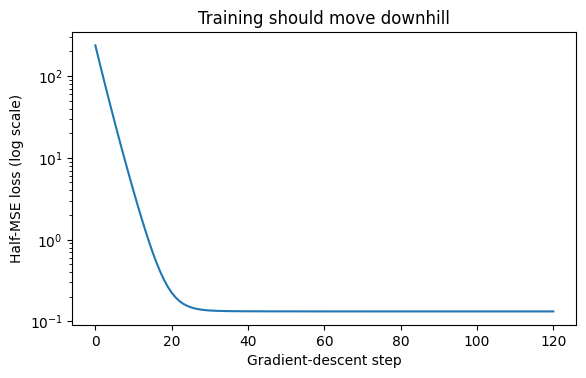

In [17]:
theta0 = np.zeros(X_train.shape[1])
theta_fit, loss_history = gradient_descent(
    X_train,
    y_train,
    theta0,
    learning_rate=0.20,
    num_steps=120,
)

train_pred = predict(X_train, theta_fit)
test_pred = predict(X_test, theta_fit)
train_rmse = np.sqrt(np.mean((train_pred - y_train) ** 2))
test_rmse = np.sqrt(np.mean((test_pred - y_test) ** 2))

print("Learned theta:", theta_fit)
print(f"Training RMSE: {train_rmse:.3f} °C")
print(f"Test RMSE:     {test_rmse:.3f} °C")
print(f"Final Gaussian NLL (sigma=1): {gaussian_nll(y_train, train_pred, sigma=1.0):.3f}")

plt.figure(figsize=(6.5, 3.8))
plt.plot(loss_history)
plt.yscale("log")
plt.xlabel("Gradient-descent step")
plt.ylabel("Half-MSE loss (log scale)")
plt.title("Training should move downhill")
plt.show()

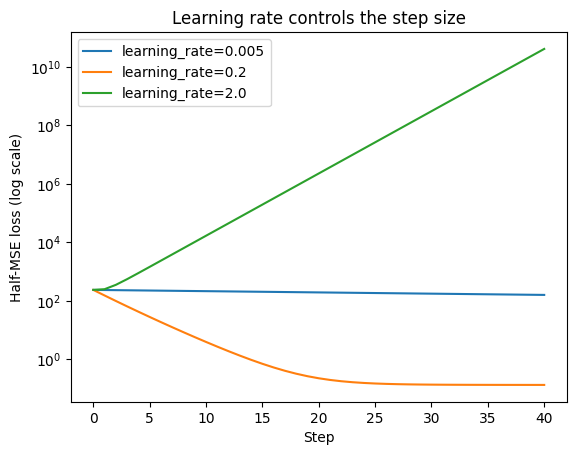

In [18]:
# Diagnostic experiment: same model, three learning rates.
for lr in [0.005, 0.20, 2.0]:
    _, h = gradient_descent(X_train, y_train, np.zeros(3), lr, 40)
    plt.plot(h, label=f"learning_rate={lr}")

plt.yscale("log")
plt.xlabel("Step")
plt.ylabel("Half-MSE loss (log scale)")
plt.title("Learning rate controls the step size")
plt.legend()
plt.show()

## Part 6 — Interpret the model (5 points, ~3 minutes)

### YOUR RESPONSE

In **2–4 sentences**, answer both questions:

1. What would it mean if one learned sensor weight were close to zero?
2. Why does low training loss not prove that the fitted parameters are literal “truth”?

**Response:** If one learned sensor was close to zero, it wouldn't add any information because the other sensors would be adding info. Low training loss could be due to correlatio vs. causation, where the actual truth isn't a cause and effect solution.


## Submission checklist

- [ ] Every required public check passes.
- [ ] The fitted loss decreases and remains finite.
- [ ] No required function name or signature was changed.
- [ ] The notebook runs after **Restart → Run all**.
- [ ] The response is 2–4 sentences.

### AI / collaboration disclosure — not graded

State `None`, or briefly describe substantive assistance used. You do not need to list ordinary syntax lookup.

**Disclosure:** Claude assistance used to create gradient descent function


# Optional Deep Dive — From “it runs” to “I trust it”

**Estimated time: 45–90+ minutes · Up to 10 bonus points**

The required assignment trains a model. The optional work asks whether the implementation is correct, how prior beliefs change the objective, and how the model can learn its own noise scale.

Complete any or all sections. Bonus points total 10.

In [19]:
# Leave a flag False to skip that optional section during Restart → Run all.
# Set it to True after you complete the corresponding function.
RUN_BONUS_A = False
RUN_BONUS_B = False
RUN_BONUS_C = False

## Bonus A — Gradient detective (3 points)

Analytic gradients are fast but easy to implement incorrectly. A centered finite difference estimates component `j` by

$$
\frac{L(\theta+\varepsilon e_j)-L(\theta-\varepsilon e_j)}{2\varepsilon}.
$$

Implement a generic numerical gradient for a scalar-valued function `loss_fn(theta)`.

In [20]:
def finite_difference_gradient(loss_fn, theta, epsilon=1e-5):
    '''Return a centered finite-difference gradient with the same shape as theta.'''
    # OPTIONAL TODO
    raise NotImplementedError("Complete finite_difference_gradient")

In [21]:
if RUN_BONUS_A:
    theta_check = np.array([0.3, -0.4, 0.8])
    loss_fn = lambda t: 0.5 * np.mean((X_train @ t - y_train) ** 2)
    numeric = finite_difference_gradient(loss_fn, theta_check)
    analytic = mse_gradient(X_train, y_train, theta_check)

    relative_error = np.linalg.norm(numeric - analytic) / max(
        1.0, np.linalg.norm(numeric), np.linalg.norm(analytic)
    )
    print("relative gradient error:", relative_error)
    assert relative_error < 1e-7
    print("✓ Bonus A public check passed")
else:
    print("○ Bonus A skipped — set RUN_BONUS_A = True when ready")

○ Bonus A skipped — set RUN_BONUS_A = True when ready


## Bonus B — A Gaussian prior becomes L2 regularization (4 points)

Suppose the non-intercept weights have a zero-mean Gaussian prior. The MAP objective can be written

$$
L_{\text{MAP}}(\theta)
= \frac{1}{2n}\|X\theta-y\|_2^2
+ \frac{\lambda}{2}\sum_{j=1}^{d-1}\theta_j^2.
$$

The intercept `theta[0]` is **not** penalized. Implement the gradient.

In [22]:
def map_gradient(X, y, theta, lam):
    '''Return the gradient of half-MSE plus L2 penalty on theta[1:].'''
    # OPTIONAL TODO
    raise NotImplementedError("Complete map_gradient")

In [23]:
if RUN_BONUS_B:
    X_tiny = np.array([[1.0, 1.0, 2.0], [1.0, -1.0, 0.5]])
    y_tiny = np.array([1.0, -1.0])
    theta_tiny = np.array([2.0, 3.0, -4.0])
    lam = 0.2
    expected = mse_gradient(X_tiny, y_tiny, theta_tiny) + np.array([0.0, 0.6, -0.8])

    assert np.allclose(map_gradient(X_tiny, y_tiny, theta_tiny, lam), expected)
    print("✓ Bonus B public check passed")
else:
    print("○ Bonus B skipped — set RUN_BONUS_B = True when ready")

○ Bonus B skipped — set RUN_BONUS_B = True when ready


## Bonus C — Learn uncertainty with a log-scale parameter (3 points)

To guarantee a positive noise scale, parameterize

$$
\sigma = e^\rho.
$$

For fixed predictions, the mean Gaussian NLL becomes

$$
L(\rho)
= \frac{1}{2}\log(2\pi) + \rho
+ \frac{1}{2}e^{-2\rho}\operatorname{mean}(r^2).
$$

Its derivative is

$$
\frac{dL}{d\rho}
= 1 - e^{-2\rho}\operatorname{mean}(r^2).
$$

Implement that derivative. Then use it to optimize `rho` and compare the learned `sigma` with the residual standard deviation.

In [24]:
def log_sigma_gradient(y, y_hat, rho):
    '''Return d(mean Gaussian NLL)/d rho where sigma = exp(rho).'''
    # OPTIONAL TODO
    raise NotImplementedError("Complete log_sigma_gradient")

In [25]:
if RUN_BONUS_C:
    rho = 0.0
    expected = 1.0 - np.mean((y_train - train_pred) ** 2)
    assert np.isclose(log_sigma_gradient(y_train, train_pred, rho), expected)
    print("✓ Bonus C public check passed")
else:
    print("○ Bonus C skipped — set RUN_BONUS_C = True when ready")

○ Bonus C skipped — set RUN_BONUS_C = True when ready


In [26]:
if RUN_BONUS_C:
    # OPTIONAL: use gradient descent on rho.
    rho = 0.0
    rho_history = [rho]
    for _ in range(100):
        # TODO: update rho using log_sigma_gradient with a learning rate such as 0.05
        pass

    # After implementing the update, uncomment:
    # sigma_learned = np.exp(rho)
    # residual_std = np.std(y_train - train_pred)
    # print("learned sigma:", sigma_learned)
    # print("residual std:", residual_std)

# Go further

Use these in roughly this order:

1. **NumPy mechanics:** [NumPy absolute basics](https://numpy.org/doc/stable/user/absolute_beginners.html) — arrays, shapes, indexing, and `axis`.
2. **Linear models as score functions:** [Stanford CS231n — Linear Classification](https://cs231n.github.io/linear-classify/) — parameterized mappings and loss functions.
3. **Optimization and gradient checking:** [Stanford CS231n — Optimization](https://cs231n.github.io/optimization-1/) — numerical versus analytic gradients, learning rates, and gradient descent.
4. **Linear algebra reference:** [Stanford CS229 linear algebra review](https://cs229.stanford.edu/section/cs229-linalg.pdf).
5. **Probability reference:** [Stanford CS229 probability review](https://cs229.stanford.edu/section/cs229-prob.pdf).
6. **Chain rule practice:** [Stanford CS224N gradient notes](https://web.stanford.edu/class/cs224n/readings/gradient-notes.pdf).
7. **Deeper matrix calculus:** [Parr & Howard, *The Matrix Calculus You Need for Deep Learning*](https://arxiv.org/abs/1802.01528).
8. **Building a neural network FROM SCRATCH (no Tensorflow/Pytorch, just numpy & math** - [this](https://www.youtube.com/watch?v=w8yWXqWQYmU$0) is the tutorial Steve recommended in class.
### A useful next question

The model above assumes a straight-line relationship, a constant noise scale, and future data drawn like the training data. Which assumption would you challenge first for a real sensor system, and what evidence would reveal that it failed?